<a href="https://colab.research.google.com/github/natifloresgz-ui/TelecomX_LATAM/blob/main/01_carga_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📌 Extracción**

In [39]:

import requests
import pandas as pd

# Cargar datos desde la API
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# 🔧 **Transformación**


In [7]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [12]:
df["account.Contract"].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [17]:
df["internet.InternetService"].unique()
df["account.PaymentMethod"].unique()
df["phone.PhoneService"].unique()

array(['Yes', 'No'], dtype=object)

In [18]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [19]:
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"],
    errors="coerce"
)

In [20]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [21]:
df["account.Charges.Total"] = df["account.Charges.Total"].fillna(0)

### Limpieza y validación de datos

Se revisaron valores ausentes, registros duplicados, tipos de datos y consistencia
en variables categóricas.  
Se corrigieron errores de formato en variables numéricas y se trataron valores
nulos para asegurar la calidad de los datos antes del análisis.

In [24]:
cols_cat = df.select_dtypes(include="object").columns

df[cols_cat] = df[cols_cat].apply(lambda x: x.str.strip().str.lower())

In [23]:
df["Churn"].unique()

array(['no', 'yes', ''], dtype=object)

In [25]:
df["Churn"] = df["Churn"].replace({"yes": 1, "no": 0})

In [26]:
df.replace(
    {
        "no internet service": "no",
        "no phone service": "no"
    },
    inplace=True
)

In [27]:
df["account.auto_payment"] = df["account.PaymentMethod"].str.contains("automatic").astype(int)

In [29]:
df["account.Contract"].unique()
df["internet.InternetService"].unique()
df["account.PaymentMethod"].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [30]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


### Corrección y estandarización de datos

Se estandarizaron las variables categóricas utilizando minúsculas y eliminación
de espacios.  
Se unificaron categorías inconsistentes y se transformó la variable objetivo
`Churn` a formato numérico.  
Además, se crearon variables derivadas para mejorar el análisis.

In [35]:
df["account.Charges.Monthly"].dtype

df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

df[["account.Charges.Monthly", "Cuentas_Diarias"]].head()


,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


### Creación de la variable Cuentas_Diarias

Se creó la variable `Cuentas_Diarias` a partir de la facturación mensual,
dividiendo el cargo mensual entre 30 días.  
Esta métrica permite analizar el gasto diario de los clientes y facilita
comparaciones más precisas en el análisis de evasión.

In [36]:
cols_binarias = [
    "customer.Partner",
    "customer.Dependents",
    "phone.PhoneService",
    "internet.OnlineSecurity",
    "internet.OnlineBackup",
    "internet.DeviceProtection",
    "internet.TechSupport",
    "internet.StreamingTV",
    "internet.StreamingMovies"
]

df[cols_binarias] = df[cols_binarias].replace({"yes": 1, "no": 0})

In [40]:
df = df.rename(columns={
    "customerID": "cliente_id",
    "customer.gender": "genero",
    "customer.SeniorCitizen": "adulto_mayor",
    "customer.tenure": "antiguedad_meses",
    "account.Contract": "tipo_contrato",
    "account.PaymentMethod": "metodo_pago",
    "account.Charges.Monthly": "cargo_mensual",
    "account.Charges.Total": "cargo_total",
    "Cuentas_Diarias": "cargo_diario"
})

In [46]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   cliente_id                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   genero                     7267 non-null   object 
 3   adulto_mayor               7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   antiguedad_meses           7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

### Estandarización y transformación de datos

Se transformaron variables categóricas binarias de formato textual a valores
numéricos (1 y 0) para facilitar el análisis y el procesamiento matemático.
Asimismo, se renombraron columnas para mejorar la claridad y comprensión de los
datos, favoreciendo su interpretación y comunicación.

# 📊 **Carga y análisis**

In [47]:
df.describe()

,adulto_mayor,antiguedad_meses,cargo_mensual
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [48]:
df.describe(include="object")

,cliente_id,Churn,genero,customer.Partner,customer.Dependents,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,tipo_contrato,account.PaperlessBilling,metodo_pago,cargo_total
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267
unique,7267,3,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531
top,9995-HOTOH,No,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2
freq,1,5174,3675,3749,5086,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445,11


In [50]:
df.groupby("Churn").describe()

adulto_mayor                                               \
             count      mean       std  min  25%  50%  75%  max   
Churn                                                             
             224.0  0.178571  0.383851  0.0  0.0  0.0  0.0  1.0   
No          5174.0  0.128721  0.334923  0.0  0.0  0.0  0.0  1.0   
Yes         1869.0  0.254682  0.435799  0.0  0.0  0.0  1.0  1.0   

      antiguedad_meses             ...             cargo_mensual             \
                 count       mean  ...   75%   max         count       mean   
Churn                              ...                                        
                 224.0  31.571429  ...  56.0  72.0         224.0  63.412277   
No              5174.0  37.569965  ...  61.0  72.0        5174.0  61.265124   
Yes             1869.0  17.979133  ...  29.0  72.0        1869.0  74.441332   

                                                          
             std    min     25%     50%      75%     max  
Churn                                                     
       31.388712  18.75  28.425  69.100  90.4125  115.55  
No     31.092648  18.25  25.100  64.425  88.4000  118.75  
Yes    24.666053  18.85  56.150  79.650  94.2000  118.35  

[3 rows x 24 columns]

### Análisis descriptivo de los datos

Se realizó un análisis descriptivo utilizando `describe()` para comprender la
distribución de las variables numéricas y categóricas.  
Las métricas de tendencia central y dispersión permiten identificar patrones
iniciales en el comportamiento de los clientes, especialmente en relación con
la evasión (Churn).

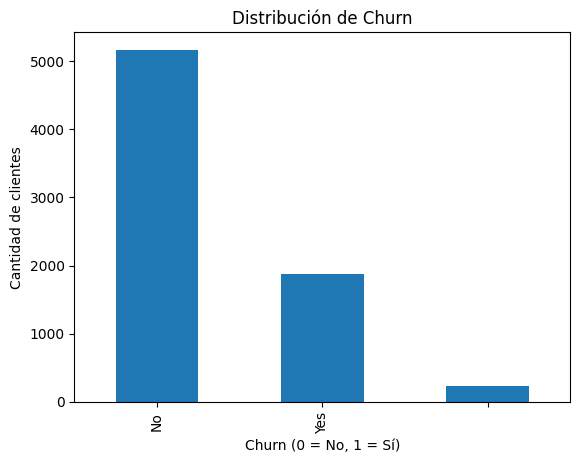

In [56]:
conteo_churn = df["Churn"].value_counts()
conteo_churn

import matplotlib.pyplot as plt

conteo_churn.plot(kind="bar")
plt.title("Distribución de Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Cantidad de clientes")
plt.show()


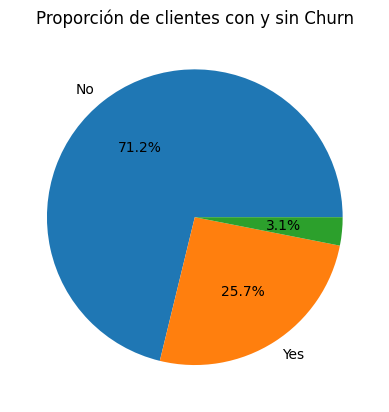

In [57]:
conteo_churn.plot(kind="pie", autopct="%1.1f%%")
plt.title("Proporción de clientes con y sin Churn")
plt.ylabel("")
plt.show()

### Distribución de la variable Churn

Se observa que la mayoría de los clientes permanece en el servicio, mientras que
una proporción menor corresponde a clientes que se dieron de baja.  
Esta distribución permite dimensionar el nivel de evasión y servirá como base
para analizar qué factores están asociados al churn.

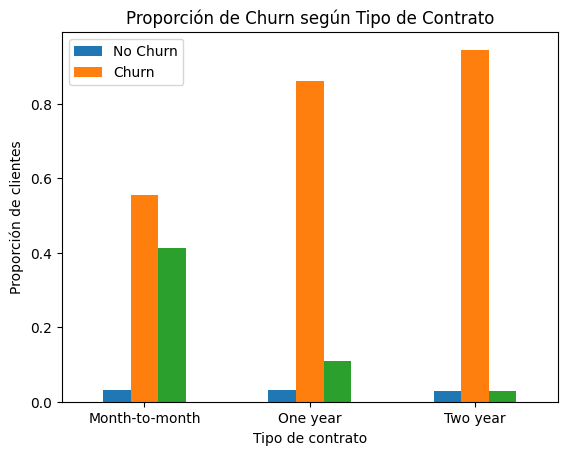

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Tabla de proporciones
tabla_contrato = pd.crosstab(
    df["tipo_contrato"],
    df["Churn"],
    normalize="index"
)

# Gráfico
tabla_contrato.plot(kind="bar")
plt.title("Proporción de Churn según Tipo de Contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Proporción de clientes")
plt.legend(["No Churn", "Churn"])
plt.xticks(rotation=0)
plt.show()

### Churn según tipo de contrato

Se observa que los clientes con contratos mensuales presentan una mayor proporción
de evasión en comparación con aquellos con contratos de mayor duración, lo que
sugiere que el tipo de contrato es un factor relevante en la retención de clientes.

In [67]:
for col in df.columns:
    print(col)


cliente_id
Churn
genero
adulto_mayor
customer.Partner
customer.Dependents
antiguedad_meses
phone.PhoneService
phone.MultipleLines
internet.InternetService
internet.OnlineSecurity
internet.OnlineBackup
internet.DeviceProtection
internet.TechSupport
internet.StreamingTV
internet.StreamingMovies
tipo_contrato
account.PaperlessBilling
metodo_pago
cargo_mensual
cargo_total


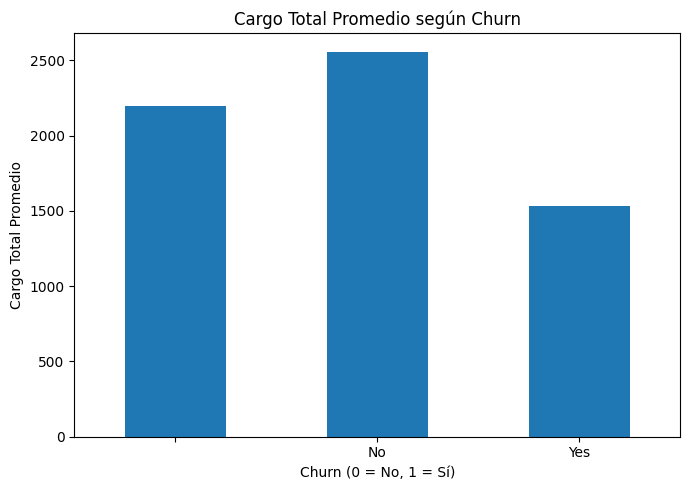

In [71]:
import matplotlib.pyplot as plt

promedio_cargo_total = df.groupby("Churn")["cargo_total"].mean()

plt.figure(figsize=(7,5))
promedio_cargo_total.plot(kind="bar")
plt.title("Cargo Total Promedio según Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Cargo Total Promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

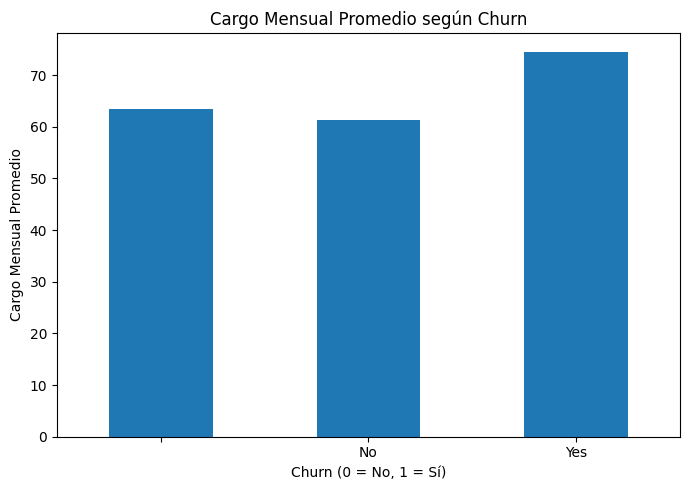

In [72]:
promedio_cargo_mensual = df.groupby("Churn")["cargo_mensual"].mean()

plt.figure(figsize=(7,5))
promedio_cargo_mensual.plot(kind="bar")
plt.title("Cargo Mensual Promedio según Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Cargo Mensual Promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

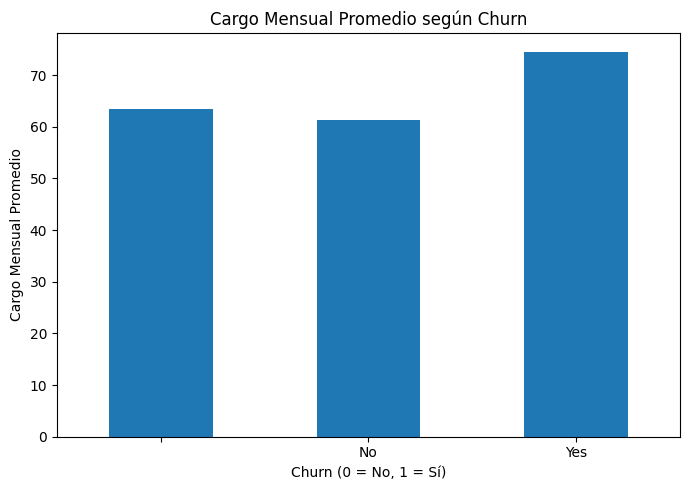

In [73]:
promedio_cargo_mensual = df.groupby("Churn")["cargo_mensual"].mean()

plt.figure(figsize=(7,5))
promedio_cargo_mensual.plot(kind="bar")
plt.title("Cargo Mensual Promedio según Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Cargo Mensual Promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Análisis de variables numéricas y churn

Los gráficos de barras muestran que los clientes que cancelaron el servicio
presentan menor antigüedad promedio y menor cargo total acumulado. Además,
se observan diferencias en el cargo mensual promedio entre los clientes que
permanecen y los que abandonan el servicio, lo que indica que estas variables
numéricas están asociadas al churn.

# **📄Informe final**

**Introducción**

El objetivo de este proyecto es analizar la evasión de clientes (Churn) en la empresa
Telecom X, identificando patrones y factores asociados a la cancelación del servicio.
El churn representa un desafío importante para la empresa, ya que la pérdida de
clientes impacta directamente en los ingresos y en la sostenibilidad del negocio.

A través del análisis exploratorio de datos, se busca comprender el perfil de los
clientes que abandonan el servicio y generar insights que ayuden a diseñar
estrategias de retención más efectivas.

**Limpieza y Tratamiento de Datos**

Los datos fueron cargados directamente desde una API en formato JSON y transformados
en un DataFrame de Pandas para facilitar su manipulación.

Durante el proceso de limpieza y tratamiento se realizaron las siguientes acciones:
- Exploración de la estructura del dataset y tipos de datos.
- Conversión de variables numéricas como cargo mensual, cargo total y antigüedad.
- Estandarización de nombres de columnas para mejorar la legibilidad.
- Revisión de valores inconsistentes y ausentes.
- Creación de nuevas variables, como métricas derivadas del gasto del cliente.

Estos pasos garantizaron que los datos estuvieran completos, coherentes y listos
para el análisis exploratorio.

**Análisis Exploratorio de Datos**

Se realizó un análisis exploratorio para comprender el comportamiento del churn
desde distintas perspectivas.

**Distribución del Churn**

Se analizaron las proporciones de clientes que permanecen y los que cancelan el
servicio, observando que la mayoría de los clientes no presenta churn, aunque existe
un porcentaje significativo de evasión.

**Variables Categóricas**

Se exploró el churn según variables como:
- Género
- Tipo de contrato
- Método de pago
- Servicios contratados

Los gráficos permitieron identificar diferencias claras, destacándose una
mayor evasión en clientes con contratos mensuales y métodos de pago no automáticos.

**Variables Numéricas**

Se analizaron variables como:
- Antigüedad del cliente
- Cargo mensual
- Cargo total acumulado

Los gráficos mostraron que los clientes que cancelan el servicio presentan,
en promedio, menor antigüedad y menor gasto total, lo que indica que la evasión ocurre
principalmente en las primeras etapas de la relación con el cliente.

**Conclusiones**

A partir del análisis realizado, se obtuvieron los siguientes hallazgos principales:

- El churn es más frecuente en clientes con menor antigüedad.
- Los contratos mensuales presentan una mayor tasa de evasión en comparación con
  contratos de mayor duración.
- Clientes con menor cargo total acumulado tienden a cancelar el servicio con mayor
  frecuencia.
- El método de pago influye en la evasión, siendo más alta en pagos manuales.

Estos resultados indican que el churn está fuertemente asociado a clientes nuevos y
a condiciones contractuales menos estables.

**Recomendaciones**

Con base en los insights obtenidos, se sugieren las siguientes acciones estratégicas:

- Implementar programas de fidelización durante los primeros meses del cliente.
- Incentivar la migración de contratos mensuales a contratos de mayor duración.
- Promover métodos de pago automáticos mediante beneficios o descuentos.
- Diseñar campañas específicas para clientes con baja antigüedad y alto riesgo
  de evasión.

La aplicación de estas estrategias puede contribuir significativamente a reducir
el churn y mejorar la retención de clientes.